# 02 — Reproduce Experiments

This is the **public reviewer-facing evaluation notebook** for the JURIX 2026 reproducibility package.

It requires only the de-identified artifacts distributed in this repository:

```text
data/
├── decision_metadata.csv
└── representations/
    ├── tfidf_matrix.npz
    ├── legalbr.npz
    ├── e5_base.npz
    ├── minilm.npz
    ├── bert_large_pt.npz
    ├── qwen3.npz
    └── bge_m3.npz
```

No judicial texts, original process identifiers, or pre-existing `results/` directory are required. The notebook creates the `results/` tree automatically.

It reproduces cosine-neighbor rankings, $R(k)$, MAE, the main figure, Friedman tests, Kendall's $W$, pairwise Wilcoxon tests with Holm correction, average ranks, and the compact results table.


In [2]:
from itertools import combinations
from pathlib import Path
import json

import numpy as np
import pandas as pd
import scipy.sparse as sp

from scipy.stats import (
    friedmanchisquare,
    rankdata,
    wilcoxon,
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt

## 1. Configuration

The default \(k\) values reproduce the local-neighborhood analysis used in the paper.

Set `INCLUDE_K_1000 = True` only for an additional large-neighborhood diagnostic; it is not required for the main paper figure.

In [3]:
REPRESENTATIONS = {
    "legalbr": "LegalBR",
    "e5_base": "E5 Base",
    "minilm": "MiniLM",
    "bert_large_pt": (
        "BERT Large PT"
    ),
    "qwen3": "Qwen3",
    "bge_m3": "BGE-M3",
    "tfidf": "TF-IDF",
}

REPRESENTATION_ORDER = [
    "legalbr",
    "e5_base",
    "minilm",
    "bert_large_pt",
    "qwen3",
    "bge_m3",
    "tfidf",
]

BASE_K_VALUES = [
    3,
    5,
    10,
    20,
    30,
    50,
    70,
    100,
    120,
    150,
]

INCLUDE_K_1000 = False

K_VALUES = (
    BASE_K_VALUES
    + (
        [1000]
        if INCLUDE_K_1000
        else []
    )
)

STATISTICAL_K_VALUES = [
    5,
    10,
    20,
]

PAPER_TABLE_K_VALUES = [
    5,
    10,
    20,
]

ALPHA = 0.05

SAVE_CASE_LEVEL_METRICS = False

# Optional: set this to the repository root if automatic detection is not desired.
REPO_ROOT_OVERRIDE = None

print(
    "Representations:",
    REPRESENTATION_ORDER,
)

print(
    "k values:",
    K_VALUES,
)

Representations: ['legalbr', 'e5_base', 'minilm', 'bert_large_pt', 'qwen3', 'bge_m3', 'tfidf']
k values: [3, 5, 10, 20, 30, 50, 70, 100, 120, 150]


## 2. Locate the reproducibility-package root

The notebook may be executed from the repository root or from `notebooks/`.

In [4]:
def find_repository_root():
    if REPO_ROOT_OVERRIDE is not None:
        candidate = Path(
            REPO_ROOT_OVERRIDE
        ).expanduser().resolve()

        metadata = (
            candidate
            / "data"
            / "decision_metadata.csv"
        )

        tfidf = (
            candidate
            / "data"
            / "representations"
            / "tfidf_matrix.npz"
        )

        if (
            metadata.exists()
            and tfidf.exists()
        ):
            return candidate

        raise FileNotFoundError(
            "REPO_ROOT_OVERRIDE does not point to a valid "
            "reproducibility-package root."
        )

    current = Path.cwd().resolve()

    search_candidates = [
        current,
        *current.parents,
    ]

    for candidate in search_candidates:
        metadata = (
            candidate
            / "data"
            / "decision_metadata.csv"
        )

        tfidf = (
            candidate
            / "data"
            / "representations"
            / "tfidf_matrix.npz"
        )

        if (
            metadata.exists()
            and tfidf.exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the reproducibility-package root.\n"
        f"Current working directory: {current}\n"
        "Expected to find:\n"
        "  data/decision_metadata.csv\n"
        "  data/representations/tfidf_matrix.npz\n"
        "Run Jupyter from the repository root (or its notebooks/ folder), "
        "or set REPO_ROOT_OVERRIDE in the configuration cell."
    )


REPO_ROOT = find_repository_root()

DATA_DIR = (
    REPO_ROOT
    / "data"
)

REPRESENTATIONS_DIR = (
    DATA_DIR
    / "representations"
)

RESULTS_DIR = (
    REPO_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

STATISTICS_DIR = (
    RESULTS_DIR
    / "statistics"
)

FIGURES_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLES_DIR = (
    RESULTS_DIR
    / "tables"
)

for directory in [
    RESULTS_DIR,
    METRICS_DIR,
    STATISTICS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    "Current working directory:",
    Path.cwd().resolve(),
)

print(
    "Repository root:",
    REPO_ROOT,
)

print(
    "Results directory:",
    RESULTS_DIR,
)

Current working directory: /home/dfrobson/Elias/Github/notebooks
Repository root: /home/dfrobson/Elias/Github
Results directory: /home/dfrobson/Elias/Github/results


## 3. Load and validate de-identified metadata

In [5]:
metadata = pd.read_csv(
    DATA_DIR
    / "decision_metadata.csv"
)

required_columns = {
    "row_index",
    "decision_id",
    "sentence_length_days",
    "crime_type",
}

missing_columns = (
    required_columns
    - set(
        metadata.columns
    )
)

if missing_columns:
    raise ValueError(
        "Missing metadata columns: "
        + ", ".join(
            sorted(
                missing_columns
            )
        )
    )

if (
    metadata[
        "decision_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Duplicate decision_id values."
    )

if not np.array_equal(
    metadata[
        "row_index"
    ].to_numpy(),
    np.arange(
        len(metadata)
    ),
):
    raise ValueError(
        "row_index must match representation row order."
    )

metadata[
    "sentence_length_days"
] = (
    metadata[
        "sentence_length_days"
    ]
    .astype(float)
)

sentence_lengths = (
    metadata[
        "sentence_length_days"
    ]
    .to_numpy(
        dtype=float
    )
)

decision_ids = (
    metadata[
        "decision_id"
    ]
    .astype(str)
    .to_numpy()
)

print(
    "Decisions:",
    len(metadata),
)

print(
    "Crime labels:",
    metadata[
        "crime_type"
    ]
    .value_counts()
    .to_dict(),
)

print(
    "Sentence-length mean:",
    sentence_lengths.mean(),
)

print(
    "Sentence-length median:",
    np.median(
        sentence_lengths
    ),
)

Decisions: 1942
Crime labels: {'simple_theft': 1942}
Sentence-length mean: 416.40422245108135
Sentence-length median: 425.0


## 4. Load all representation matrices

All rows must match `decision_metadata.csv`.

Dense arrays are stored as compressed NumPy archives, while TF-IDF is stored as a sparse SciPy matrix.

In [6]:
representation_matrices = {}

for representation_id in (
    REPRESENTATION_ORDER
):
    if representation_id == "tfidf":
        matrix = (
            sp.load_npz(
                REPRESENTATIONS_DIR
                / "tfidf_matrix.npz"
            )
            .tocsr()
        )

    else:
        archive = np.load(
            REPRESENTATIONS_DIR
            / f"{representation_id}.npz"
        )

        if (
            "embeddings"
            not in archive.files
        ):
            raise ValueError(
                f"{representation_id}.npz "
                "does not contain an 'embeddings' array."
            )

        matrix = np.asarray(
            archive[
                "embeddings"
            ],
            dtype=np.float32,
        )

    if (
        matrix.shape[0]
        != len(metadata)
    ):
        raise ValueError(
            f"Row mismatch for {representation_id}: "
            f"{matrix.shape[0]} vs {len(metadata)}."
        )

    representation_matrices[
        representation_id
    ] = matrix

    print(
        representation_id,
        matrix.shape,
    )

legalbr (1942, 1024)
e5_base (1942, 768)
minilm (1942, 384)
bert_large_pt (1942, 1024)
qwen3 (1942, 1024)
bge_m3 (1942, 1024)
tfidf (1942, 19404)


## 5. Metric definitions

For each representation \(m\) and query decision \(i\), let \(N_k^{(m)}(i)\) be the \(k\) nearest decisions according to cosine similarity.

The neighborhood variance ratio is:

\[
R(k) =
\frac{
    \frac{1}{n}
    \sum_{i=1}^{n}
    \mathrm{Var}
    \left(
        \{s_j : j \in N_k^{(m)}(i)\}
    \right)
}{
    \mathrm{Var}
    \left(
        \{s_1,\ldots,s_n\}
    \right)
}.
\]

Interpretation:

- \(R(k)<1\): neighborhoods have more homogeneous sentence lengths than the complete dataset;
- \(R(k)=1\): neighborhood variance matches the global reference;
- \(R(k)>1\): neighborhoods are more heterogeneous than the global reference.

Lower values are preferred under this criterion.

The neighbor-based MAE uses the mean sentence length among the \(k\) nearest neighbors as the estimate for the query decision.

In [7]:
def compute_similarity_and_ranking(
    matrix,
):
    matrix_normalized = normalize(
        matrix,
        norm="l2",
        axis=1,
        copy=True,
    )

    similarity = cosine_similarity(
        matrix_normalized
    ).astype(
        np.float32
    )

    np.fill_diagonal(
        similarity,
        -np.inf,
    )

    ranking = np.argsort(
        -similarity,
        axis=1,
    )

    return (
        similarity,
        ranking,
    )


def evaluate_ranking(
    representation_id,
    ranking,
):
    n = len(
        sentence_lengths
    )

    global_variance = np.var(
        sentence_lengths
    )

    baseline_value = np.median(
        sentence_lengths
    )

    baseline_mae = np.mean(
        np.abs(
            sentence_lengths
            - baseline_value
        )
    )

    aggregate_records = []
    case_records = []

    for k in K_VALUES:
        if k >= n:
            print(
                f"Skipping k={k} "
                f"for {representation_id}: "
                f"n={n}."
            )

            continue

        neighbor_indices = (
            ranking[
                :,
                :k,
            ]
        )

        neighbor_sentences = (
            sentence_lengths[
                neighbor_indices
            ]
        )

        local_variance = np.var(
            neighbor_sentences,
            axis=1,
        )

        local_r = (
            local_variance
            / global_variance
        )

        neighbor_mean = np.mean(
            neighbor_sentences,
            axis=1,
        )

        absolute_error = np.abs(
            sentence_lengths
            - neighbor_mean
        )

        r_k = np.mean(
            local_r
        )

        mae_days = np.mean(
            absolute_error
        )

        aggregate_records.append({
            "representation_id": (
                representation_id
            ),
            "representation_name": (
                REPRESENTATIONS[
                    representation_id
                ]
            ),
            "n_decisions": n,
            "k": k,
            "R_k": r_k,
            "MAE_days": mae_days,
            "MAE_baseline_days": (
                baseline_mae
            ),
            "MAE_reduction_vs_baseline_pct": (
                (
                    1
                    - mae_days
                    / baseline_mae
                )
                * 100
            ),
            "global_variance": (
                global_variance
            ),
            "mean_local_variance": (
                np.mean(
                    local_variance
                )
            ),
        })

        if (
            k
            in STATISTICAL_K_VALUES
        ):
            for i in range(n):
                case_records.append({
                    "decision_id": (
                        decision_ids[
                            i
                        ]
                    ),
                    "representation_id": (
                        representation_id
                    ),
                    "representation_name": (
                        REPRESENTATIONS[
                            representation_id
                        ]
                    ),
                    "k": k,
                    "sentence_length_days": (
                        sentence_lengths[
                            i
                        ]
                    ),
                    "neighbor_sentence_mean": (
                        neighbor_mean[
                            i
                        ]
                    ),
                    "local_variance": (
                        local_variance[
                            i
                        ]
                    ),
                    "local_R": (
                        local_r[
                            i
                        ]
                    ),
                    "absolute_error_days": (
                        absolute_error[
                            i
                        ]
                    ),
                    "global_variance": (
                        global_variance
                    ),
                })

    return (
        aggregate_records,
        case_records,
    )

## 6. Evaluate the seven representations

Each similarity matrix is released before moving to the next representation to reduce memory usage.

In [8]:
aggregate_records = []
case_level_records = []

for representation_id in (
    REPRESENTATION_ORDER
):
    print(
        "\n"
        + "=" * 80
    )

    print(
        "Evaluating:",
        REPRESENTATIONS[
            representation_id
        ],
    )

    matrix = (
        representation_matrices[
            representation_id
        ]
    )

    (
        similarity,
        ranking,
    ) = compute_similarity_and_ranking(
        matrix
    )

    (
        representation_aggregate,
        representation_case_level,
    ) = evaluate_ranking(
        representation_id=(
            representation_id
        ),
        ranking=ranking,
    )

    aggregate_records.extend(
        representation_aggregate
    )

    case_level_records.extend(
        representation_case_level
    )

    del similarity
    del ranking


df_metrics = pd.DataFrame(
    aggregate_records
)

df_case_metrics = pd.DataFrame(
    case_level_records
)

display(
    df_metrics.round(
        4
    )
)


Evaluating: LegalBR

Evaluating: E5 Base

Evaluating: MiniLM

Evaluating: BERT Large PT

Evaluating: Qwen3

Evaluating: BGE-M3

Evaluating: TF-IDF


,representation_id,representation_name,n_decisions,k,R_k,MAE_days,MAE_baseline_days,MAE_reduction_vs_baseline_pct,global_variance,mean_local_variance
0,legalbr,LegalBR,1942,3,0.5959,125.1255,122.0139,-2.5502,28978.0771,17267.0433
1,legalbr,LegalBR,1942,5,0.7003,117.1578,122.0139,3.9800,28978.0771,20294.0922
2,legalbr,LegalBR,1942,10,0.8234,113.2487,122.0139,7.1838,28978.0771,23860.5446
3,legalbr,LegalBR,1942,20,0.8872,111.0429,122.0139,8.9916,28978.0771,25709.7284
4,legalbr,LegalBR,1942,30,0.9096,110.6550,122.0139,9.3095,28978.0771,26358.4609
...,...,...,...,...,...,...,...,...,...,...
65,tfidf,TF-IDF,1942,50,1.0035,112.4094,122.0139,7.8717,28978.0771,29079.9154
66,tfidf,TF-IDF,1942,70,1.0256,112.4493,122.0139,7.8389,28978.0771,29719.0178
67,tfidf,TF-IDF,1942,100,1.0443,112.4375,122.0139,7.8486,28978.0771,30260.8486
68,tfidf,TF-IDF,1942,120,1.0485,112.7603,122.0139,7.5840,28978.0771,30383.6781


## 7. Save aggregate metrics

In [9]:
metrics_path = (
    METRICS_DIR
    / "rk_mae.csv"
)

df_metrics.to_csv(
    metrics_path,
    index=False,
)

if SAVE_CASE_LEVEL_METRICS:
    df_case_metrics.to_csv(
        METRICS_DIR
        / "case_level_metrics.csv",
        index=False,
    )

print(
    "Saved:",
    metrics_path,
)

Saved: /home/dfrobson/Elias/Github/results/metrics/rk_mae.csv


## 8. Reproduce the paper's \(R(k)\) figure

TF-IDF is shown with a dashed black line to distinguish the sparse lexical representation from the six dense representations.

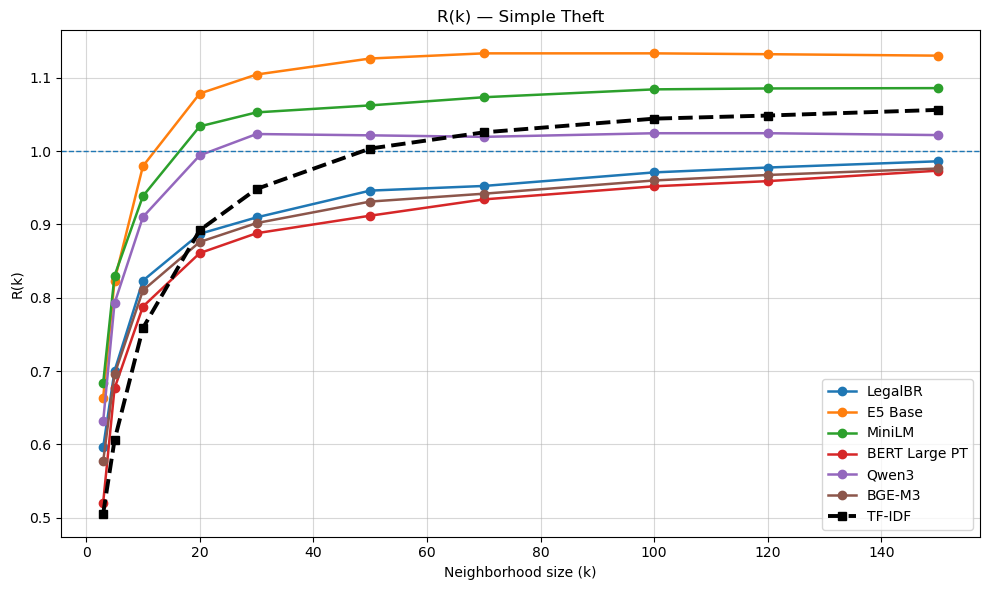

Saved: /home/dfrobson/Elias/Github/results/figures/rk_all_representations.png
Saved: /home/dfrobson/Elias/Github/results/figures/rk_all_representations.pdf


In [10]:
plt.figure(
    figsize=(10, 6)
)

for representation_id in (
    REPRESENTATION_ORDER
):
    data = (
        df_metrics[
            df_metrics[
                "representation_id"
            ].eq(
                representation_id
            )
        ]
        .sort_values(
            "k"
        )
    )

    if data.empty:
        continue

    if (
        representation_id
        == "tfidf"
    ):
        plt.plot(
            data["k"],
            data["R_k"],
            marker="s",
            linestyle="--",
            linewidth=2.8,
            color="black",
            zorder=10,
            label=(
                REPRESENTATIONS[
                    representation_id
                ]
            ),
        )

    else:
        plt.plot(
            data["k"],
            data["R_k"],
            marker="o",
            linewidth=1.8,
            label=(
                REPRESENTATIONS[
                    representation_id
                ]
            ),
        )

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

if INCLUDE_K_1000:
    plt.xscale(
        "log"
    )

plt.xlabel(
    "Neighborhood size (k)"
)

plt.ylabel(
    "R(k)"
)

plt.title(
    "R(k) — Simple Theft"
)

plt.legend()

plt.grid(
    True,
    alpha=0.5,
)

plt.tight_layout()

figure_png = (
    FIGURES_DIR
    / "rk_all_representations.png"
)

figure_pdf = (
    FIGURES_DIR
    / "rk_all_representations.pdf"
)

plt.savefig(
    figure_png,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figure_pdf,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    figure_png,
)

print(
    "Saved:",
    figure_pdf,
)

## 9. Compact paper table

In [11]:
paper_rows = []

for representation_id in (
    REPRESENTATION_ORDER
):
    row = {
        "Representation": (
            REPRESENTATIONS[
                representation_id
            ]
        ),
    }

    model_data = (
        df_metrics[
            df_metrics[
                "representation_id"
            ].eq(
                representation_id
            )
        ]
        .set_index(
            "k"
        )
    )

    for k in (
        PAPER_TABLE_K_VALUES
    ):
        row[
            f"R@{k}"
        ] = (
            model_data.loc[
                k,
                "R_k",
            ]
            if k
            in model_data.index
            else np.nan
        )

        row[
            f"MAE@{k}"
        ] = (
            model_data.loc[
                k,
                "MAE_days",
            ]
            if k
            in model_data.index
            else np.nan
        )

    paper_rows.append(
        row
    )


df_paper_table = pd.DataFrame(
    paper_rows
)

df_paper_table.to_csv(
    TABLES_DIR
    / "main_results.csv",
    index=False,
)

display(
    df_paper_table.round(
        3
    )
)

,Representation,R@5,MAE@5,R@10,MAE@10,R@20,MAE@20
0,LegalBR,0.700,117.158,0.823,113.249,0.887,111.043
1,E5 Base,0.823,128.847,0.979,121.086,1.078,119.793
2,MiniLM,0.830,125.777,0.939,119.444,1.034,117.301
3,BERT Large PT,0.676,118.580,0.788,115.350,0.861,113.757
4,Qwen3,0.793,119.362,0.910,115.034,0.994,113.056
5,BGE-M3,0.696,115.118,0.810,111.241,0.876,109.420
6,TF-IDF,0.606,117.184,0.759,113.558,0.892,112.425


# Statistical comparison

The same decision is evaluated under every representation, yielding a paired repeated-measures design.

For each \(k \in \{5,10,20\}\), the notebook applies:

\[
\text{Friedman omnibus test}
\rightarrow
\text{Wilcoxon signed-rank post-hoc tests}
\rightarrow
\text{Holm correction}.
\]

Kendall's \(W\) is reported as the omnibus effect size.

In [12]:
STATISTICAL_METRICS = {
    "local_R": "Local R",
    "absolute_error_days": (
        "Absolute error (days)"
    ),
}


def build_paired_matrix(
    dataframe,
    metric,
    k,
):
    subset = (
        dataframe[
            dataframe[
                "k"
            ].eq(
                k
            )
        ][
            [
                "decision_id",
                "representation_id",
                metric,
            ]
        ]
    )

    pivot = (
        subset.pivot(
            index="decision_id",
            columns=(
                "representation_id"
            ),
            values=metric,
        )
    )

    available_order = [
        representation_id
        for representation_id
        in REPRESENTATION_ORDER
        if representation_id
        in pivot.columns
    ]

    return (
        pivot[
            available_order
        ]
        .dropna(
            axis=0,
            how="any",
        )
    )

## 10. Friedman tests and Kendall's \(W\)

In [13]:
paired_matrices = {}
friedman_records = []

for metric, metric_label in (
    STATISTICAL_METRICS.items()
):
    for k in (
        STATISTICAL_K_VALUES
    ):
        paired = (
            build_paired_matrix(
                dataframe=(
                    df_case_metrics
                ),
                metric=metric,
                k=k,
            )
        )

        if (
            paired.shape[1]
            < 3
        ):
            raise ValueError(
                "Friedman requires at least "
                "three representations."
            )

        statistic, p_value = (
            friedmanchisquare(
                *[
                    paired[
                        representation_id
                    ].to_numpy(
                        dtype=float
                    )
                    for representation_id
                    in paired.columns
                ]
            )
        )

        n_cases = (
            paired.shape[0]
        )

        n_representations = (
            paired.shape[1]
        )

        kendalls_w = (
            statistic
            / (
                n_cases
                * (
                    n_representations
                    - 1
                )
            )
        )

        friedman_records.append({
            "metric": metric,
            "metric_label": (
                metric_label
            ),
            "k": k,
            "n_cases": n_cases,
            "n_representations": (
                n_representations
            ),
            "friedman_chi2": (
                statistic
            ),
            "p_value_raw": (
                p_value
            ),
            "kendalls_W": (
                kendalls_w
            ),
        })

        paired_matrices[
            (
                metric,
                k,
            )
        ] = paired


df_friedman = pd.DataFrame(
    friedman_records
)

(
    reject,
    p_adjusted,
    _,
    _,
) = multipletests(
    df_friedman[
        "p_value_raw"
    ].to_numpy(),
    alpha=ALPHA,
    method="holm",
)

df_friedman[
    "p_value_holm"
] = p_adjusted

df_friedman[
    "significant_holm"
] = reject

df_friedman.to_csv(
    STATISTICS_DIR
    / "friedman_tests.csv",
    index=False,
)

display(
    df_friedman.round(
        6
    )
)

,metric,metric_label,k,n_cases,n_representations,friedman_chi2,p_value_raw,kendalls_W,p_value_holm,significant_holm
0,local_R,Local R,5,1942,7,272.915547,0.0,0.023422,0.0,True
1,local_R,Local R,10,1942,7,434.832778,0.0,0.037318,0.0,True
2,local_R,Local R,20,1942,7,665.151322,0.0,0.057085,0.0,True
3,absolute_error_days,Absolute error (days),5,1942,7,65.409986,0.0,0.005614,0.0,True
4,absolute_error_days,Absolute error (days),10,1942,7,46.412357,0.0,0.003983,0.0,True
5,absolute_error_days,Absolute error (days),20,1942,7,91.703619,0.0,0.007870,0.0,True


## 11. Average within-case ranks

Lower average rank is better because both statistical metrics are minimized.

In [14]:
average_rank_records = []

for (
    metric,
    k,
), paired in (
    paired_matrices.items()
):
    values = paired.to_numpy(
        dtype=float
    )

    ranks = np.apply_along_axis(
        lambda row: rankdata(
            row,
            method="average",
        ),
        axis=1,
        arr=values,
    )

    mean_ranks = np.mean(
        ranks,
        axis=0,
    )

    for column_index, representation_id in enumerate(
        paired.columns
    ):
        average_rank_records.append({
            "metric": metric,
            "metric_label": (
                STATISTICAL_METRICS[
                    metric
                ]
            ),
            "k": k,
            "representation_id": (
                representation_id
            ),
            "representation_name": (
                REPRESENTATIONS[
                    representation_id
                ]
            ),
            "average_rank": float(
                mean_ranks[
                    column_index
                ]
            ),
        })


df_average_ranks = pd.DataFrame(
    average_rank_records
)

df_average_ranks.to_csv(
    STATISTICS_DIR
    / "average_ranks.csv",
    index=False,
)

display(
    df_average_ranks.round(
        4
    )
)

,metric,metric_label,k,representation_id,representation_name,average_rank
0,local_R,Local R,5,legalbr,LegalBR,3.7799
1,local_R,Local R,5,e5_base,E5 Base,4.5309
2,local_R,Local R,5,minilm,MiniLM,4.1815
3,local_R,Local R,5,bert_large_pt,BERT Large PT,3.8012
4,local_R,Local R,5,qwen3,Qwen3,4.1645
5,local_R,Local R,5,bge_m3,BGE-M3,4.0121
6,local_R,Local R,5,tfidf,TF-IDF,3.5299
7,local_R,Local R,10,legalbr,LegalBR,3.7073
8,local_R,Local R,10,e5_base,E5 Base,4.7536
9,local_R,Local R,10,minilm,MiniLM,4.1921


## 12. Pairwise Wilcoxon tests with Holm correction

The matched-pairs rank-biserial correlation is reported as an effect-size estimate.

With \(d_i=A_i-B_i\), a negative rank-biserial value indicates that representation A tends to have lower (better) metric values than representation B.

In [15]:
def matched_rank_biserial(
    a,
    b,
):
    a = np.asarray(
        a,
        dtype=float,
    )

    b = np.asarray(
        b,
        dtype=float,
    )

    differences = (
        a - b
    )

    differences = (
        differences[
            differences != 0
        ]
    )

    if (
        len(
            differences
        )
        == 0
    ):
        return 0.0

    ranks = rankdata(
        np.abs(
            differences
        ),
        method="average",
    )

    positive_sum = np.sum(
        ranks[
            differences > 0
        ]
    )

    negative_sum = np.sum(
        ranks[
            differences < 0
        ]
    )

    denominator = (
        positive_sum
        + negative_sum
    )

    if denominator == 0:
        return 0.0

    return (
        positive_sum
        - negative_sum
    ) / denominator


def safe_wilcoxon(
    a,
    b,
):
    a = np.asarray(
        a,
        dtype=float,
    )

    b = np.asarray(
        b,
        dtype=float,
    )

    if np.all(
        a == b
    ):
        return (
            0.0,
            1.0,
        )

    result = wilcoxon(
        a,
        b,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto",
    )

    return (
        float(
            result.statistic
        ),
        float(
            result.pvalue
        ),
    )

In [16]:
posthoc_records = []

for (
    metric,
    k,
), paired in (
    paired_matrices.items()
):
    omnibus = (
        df_friedman[
            (
                df_friedman[
                    "metric"
                ].eq(
                    metric
                )
            )
            & (
                df_friedman[
                    "k"
                ].eq(
                    k
                )
            )
        ]
        .iloc[
            0
        ]
    )

    if not bool(
        omnibus[
            "significant_holm"
        ]
    ):
        continue

    family_records = []

    for (
        representation_a,
        representation_b,
    ) in combinations(
        paired.columns,
        2,
    ):
        a = (
            paired[
                representation_a
            ]
            .to_numpy(
                dtype=float
            )
        )

        b = (
            paired[
                representation_b
            ]
            .to_numpy(
                dtype=float
            )
        )

        statistic, p_value = (
            safe_wilcoxon(
                a,
                b,
            )
        )

        difference = (
            a - b
        )

        family_records.append({
            "metric": metric,
            "metric_label": (
                STATISTICAL_METRICS[
                    metric
                ]
            ),
            "k": k,
            "representation_a": (
                representation_a
            ),
            "representation_a_name": (
                REPRESENTATIONS[
                    representation_a
                ]
            ),
            "representation_b": (
                representation_b
            ),
            "representation_b_name": (
                REPRESENTATIONS[
                    representation_b
                ]
            ),
            "n_pairs": len(a),
            "wilcoxon_statistic": (
                statistic
            ),
            "p_value_raw": (
                p_value
            ),
            "mean_difference_A_minus_B": (
                np.mean(
                    difference
                )
            ),
            "median_difference_A_minus_B": (
                np.median(
                    difference
                )
            ),
            "pct_A_lower": (
                np.mean(
                    a < b
                )
                * 100
            ),
            "pct_B_lower": (
                np.mean(
                    b < a
                )
                * 100
            ),
            "pct_tie": (
                np.mean(
                    a == b
                )
                * 100
            ),
            "rank_biserial_A_minus_B": (
                matched_rank_biserial(
                    a,
                    b,
                )
            ),
        })

    family_df = pd.DataFrame(
        family_records
    )

    (
        reject,
        p_adjusted,
        _,
        _,
    ) = multipletests(
        family_df[
            "p_value_raw"
        ].to_numpy(),
        alpha=ALPHA,
        method="holm",
    )

    family_df[
        "p_value_holm"
    ] = p_adjusted

    family_df[
        "significant_holm"
    ] = reject

    posthoc_records.extend(
        family_df.to_dict(
            orient="records"
        )
    )


df_posthoc = pd.DataFrame(
    posthoc_records
)

df_posthoc.to_csv(
    STATISTICS_DIR
    / "wilcoxon_holm.csv",
    index=False,
)

display(
    df_posthoc.round(
        6
    )
)

,metric,metric_label,k,representation_a,representation_a_name,representation_b,representation_b_name,n_pairs,wilcoxon_statistic,p_value_raw,mean_difference_A_minus_B,median_difference_A_minus_B,pct_A_lower,pct_B_lower,pct_tie,rank_biserial_A_minus_B,p_value_holm,significant_holm
0,local_R,Local R,5,legalbr,LegalBR,e5_base,E5 Base,1942,684012.5,0.000000,-0.122957,-0.137451,59.629248,39.701339,0.669413,-0.265089,0.000000,True
1,local_R,Local R,5,legalbr,LegalBR,minilm,MiniLM,1942,773042.5,0.000000,-0.129638,-0.062674,54.891864,44.078270,1.029866,-0.163375,0.000000,True
2,local_R,Local R,5,legalbr,LegalBR,bert_large_pt,BERT Large PT,1942,897680.5,0.417899,0.023996,-0.007399,50.978373,47.631308,1.390319,-0.021372,0.835799,False
3,local_R,Local R,5,legalbr,LegalBR,qwen3,Qwen3,1942,783247.5,0.000000,-0.092212,-0.060233,55.355304,43.717817,0.926880,-0.154092,0.000000,True
4,local_R,Local R,5,legalbr,LegalBR,bge_m3,BGE-M3,1942,853135.5,0.001949,0.004701,-0.034717,52.832132,46.395469,0.772400,-0.081479,0.009448,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,absolute_error_days,Absolute error (days),20,bert_large_pt,BERT Large PT,bge_m3,BGE-M3,1942,861967.0,0.001133,4.337049,2.475000,47.425335,52.523172,0.051493,0.085306,0.013597,True
122,absolute_error_days,Absolute error (days),20,bert_large_pt,BERT Large PT,tfidf,TF-IDF,1942,919195.5,0.328870,1.331977,1.600000,48.558187,51.441813,0.000000,0.025581,0.986610,False
123,absolute_error_days,Absolute error (days),20,qwen3,Qwen3,bge_m3,BGE-M3,1942,871541.0,0.003677,3.635659,2.050000,47.940268,52.059732,0.000000,0.076098,0.040450,True
124,absolute_error_days,Absolute error (days),20,qwen3,Qwen3,tfidf,TF-IDF,1942,931087.5,0.648189,0.630587,0.050000,49.948507,50.000000,0.051493,0.011957,1.000000,False


## 13. Final output summary

In [17]:
print(
    "Generated results:"
)

for path in sorted(
    RESULTS_DIR.rglob(
        "*"
    )
):
    if path.is_file():
        print(
            "-",
            path.relative_to(
                REPO_ROOT
            ),
        )

Generated results:
- results/figures/rk_all_representations.pdf
- results/figures/rk_all_representations.png
- results/metrics/rk_mae.csv
- results/statistics/average_ranks.csv
- results/statistics/friedman_tests.csv
- results/statistics/wilcoxon_holm.csv
- results/tables/main_results.csv
